In [1]:
import pandas as pd

from utils import plot_utils

FilePath = r"C:\imageripping\m6d1\20260124_timeseries_m6_d1_900_las500p900_29.3fps_1x_int187_tonepuff-223\20260124_timeseries_m6_d1_900_las500p900_29.3fps_1x_int187_tonepuff-223_Cycle00001_VoltageRecording_001.csv"
df = pd.read_csv(FilePath)

In [10]:
from utils.plot_utils import PlotUtils
from utils.data_utils import DataUtils
from utils.file_utils import FileUtils
from utils.analysis_util import AnalysisUtil
from utils.path_utils import PathUtils

In [4]:
neuro_data = DataUtils.filter_rows_by_threshold(df, 1, 5, ">=")

In [ ]:
PlotUtils.draw_line_plot(
    neuro_data.iloc[:, -2],
    y_label=neuro_data.columns[-2],
    title="Voltage over time"
)

In [ ]:
from utils.analysis_util import AnalysisUtil
peaks, time = AnalysisUtil.find_event(neuro_data, 5, 0, prominence = 1, values = True)

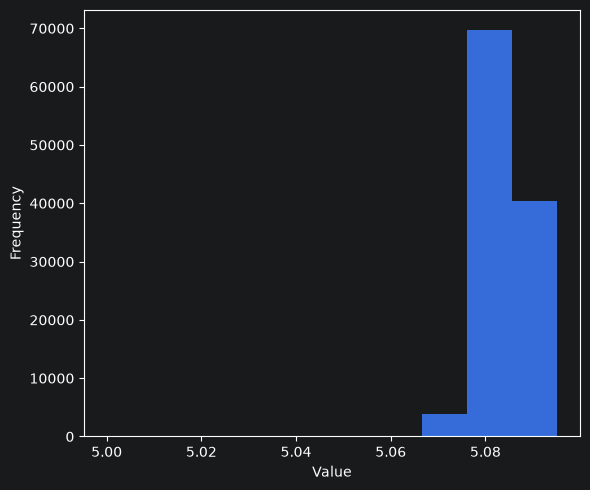

In [16]:
PlotUtils.draw_histogram(neuro_data.iloc[:,1], bins = 10)

In [17]:
neuro_data.iloc[:,1]

1           5.085144
1026        5.089417
1027        5.081482
2049        5.081177
3075        5.080872
              ...   
63443264    5.087585
63444286    5.080261
63444287    5.081787
63445309    5.090637
63445310    5.086060
Name:  Frame begin, Length: 114544, dtype: float64

In [13]:
F_path = r"C:\imageripping\m6d1\20260124_timeseries_m6_d1_900_las500p900_29.3fps_1x_int187_tonepuff-223\suite2p\plane0\Fall.mat"
suite2p_data = FileUtils.read_mat_file(F_path)

In [14]:
print(suite2p_data.keys())
F = suite2p_data['F']

dict_keys(['__header__', '__version__', '__globals__', 'stat', 'ops', 'F', 'Fneu', 'spks', 'iscell', 'redcell'])


In [15]:
F

array([[ 64.63144 ,  81.73183 ,  90.35979 , ...,  41.736073,  43.210186,
         65.146126],
       [376.46188 , 162.93333 , 329.72488 , ..., 367.35864 , 194.84698 ,
        212.88092 ],
       [ 42.17794 , 214.37474 , 189.63924 , ..., 161.13737 , 206.71112 ,
         53.64132 ],
       ...,
       [105.88441 , 140.51135 , 207.06209 , ..., 157.63072 , 160.36043 ,
        151.72458 ],
       [129.9508  , 107.92084 , 103.64945 , ..., 103.18943 , 198.60341 ,
         95.428764],
       [ 99.13013 , 291.45483 ,  32.279346, ..., 185.05928 ,  42.670258,
         79.70181 ]], shape=(316, 140725), dtype=float32)

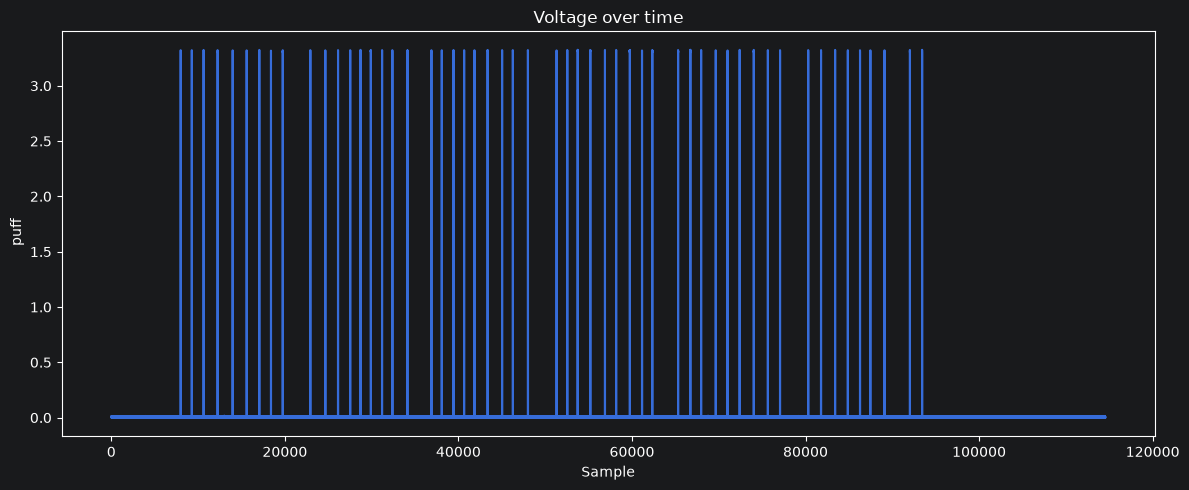

In [4]:
from utils.path_utils import PathUtils
mouse_id = PathUtils.extract_mouse_id(FilePath)
mouse_dir = PathUtils.make_mouse_plot_dir(mouse_id)
PlotUtils.draw_line_plot(
        neuro_data.iloc[:, -1],
        y_label=neuro_data.columns[-1],
        title="Voltage over time",
        save_path = PathUtils.join_path(mouse_dir, f"{mouse_id}_{neuro_data.columns[-1]}.png")
    )

In [7]:
tone_peaks, tone_peaks_time = AnalysisUtil.find_event(neuro, " tone",
                                                          "Time(ms)", values = True)

'C:\\Users\\HoLab4\\Yuchang\\DataAlign\\plots\\m6d1'

In [7]:
neuro_data

,Time(ms),Frame begin,behaviorcamframes,optostim,pmtshutterclosing,tone,puff
1,3.335001e-02,5.085144,2.255249,-0.039062,0.003815,0.543518,0.009766
1026,3.421711e+01,5.089417,1.037598,-0.041504,0.003510,0.541382,0.003357
1027,3.425046e+01,5.081482,1.043091,-0.039978,0.003967,0.543518,0.010681
2049,6.833417e+01,5.081177,1.032104,-0.039673,0.003815,0.530090,0.008545
3075,1.025513e+02,5.080872,1.033020,-0.040894,0.004120,0.539246,0.010681
...,...,...,...,...,...,...,...
63443264,2.115833e+06,5.087585,0.265503,-0.039673,0.004730,0.529175,0.005188
63444286,2.115867e+06,5.080261,0.267639,-0.039978,0.004120,0.529785,0.004578
63444287,2.115868e+06,5.081787,0.279236,-0.039673,0.005035,0.529785,0.007935
63445309,2.115902e+06,5.090637,0.265503,-0.039368,0.004883,0.527344,0.006714


In [8]:
filtered_voltage_data = DataUtils.reset_row_numbers(neuro_data, drop = True)

tone_peaks, tone_peaks_time = AnalysisUtil.find_event(filtered_voltage_data, " tone",
                                                          "Time(ms)", values = True)

tone_peaks_time = DataUtils.reset_row_numbers(tone_peaks_time, drop = False)

tone_peaks_time

,index,Time(ms)
0,274,5.185593e+03
1,1834,3.411492e+04
2,3083,5.704015e+04
3,4698,8.699283e+04
4,6322,1.169116e+05
...,...,...
60,87426,1.615608e+06
61,89053,1.645595e+06
62,90303,1.668623e+06
63,91985,1.699667e+06


In [11]:
mouse_id = PathUtils.extract_mouse_id(FilePath)
mouse_dir = PathUtils.make_mouse_file_dir(mouse_id)
path = PathUtils.join_path(mouse_dir, f"{mouse_id}_{filtered_voltage_data.columns[-1]}.csv")
FileUtils.write_csv_file(path, tone_peaks_time)

In [12]:
path

'C:\\Users\\HoLab4\\Yuchang\\DataAlign\\files\\m6d1\\m6d1_ puff.csv'